## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS
* **P (Performance / Desempeño):** Maximizar créditos otorgados a clientes solventes y minimizar la tasa de morosidad e impagos del banco.
* **E (Environment / Entorno):** Sistema informático de evaluación del banco y base de datos de solicitudes entrantes.
* **A (Actuators / Actuadores):** Emitir el dictamen final de la solicitud: "aprobar", "aprobar con condiciones" o "rechazar".
* **S (Sensors / Sensores):** Entrada de datos: `ingreso_mensual`, `monto_solicitado` y `tiene_historial_moroso`.

### Justificación de las reglas
Las reglas se basan en la gestión de riesgo crediticio de la institución bancaria. El historial moroso se define como un criterio de exclusión estricto, rechazando automáticamente la solicitud sin importar el nivel de ingresos del cliente. Para clientes sin antecedentes de morosidad, se evalúa la capacidad de pago mediante la relación monto/ingreso: un valor menor o igual a 0.30 representa bajo riesgo e ingresos holgados (aprobar), entre 0.30 y 0.50 refleja un nivel de endeudamiento moderado que requiere garantías adicionales (aprobar con condiciones), y un valor superior a 0.50 supera el umbral tolerable de endeudamiento (rechazar).

### Código

In [10]:
### Código
def agente_soporte(tiempo_espera_minutos, nivel_urgencia, cliente_premium):
    if cliente_premium or nivel_urgencia == "alta":
        return "escalar a Nivel 3", "cliente premium o problema de alta urgencia"
    elif nivel_urgencia == "media" or tiempo_espera_minutos > 30:
        return "escalar a Nivel 2", "urgencia media o tiempo de espera elevado (>30 min)"
    else:
        return "escalar a Nivel 1", "urgencia baja y tiempo de espera aceptable"

In [11]:
# Celda de Simulación (6 casos con límites)
casos_prueba = [
    (5000, 1000, False),  # 0.20 -> Aprobar
    (3000, 900, False),   # 0.30 (Límite) -> Aprobar
    (4000, 1600, False),  # 0.40 -> Aprobar con condiciones
    (3000, 1500, False),  # 0.50 (Límite) -> Aprobar con condiciones
    (4000, 2500, False),  # 0.625 -> Rechazar
    (8000, 1000, True)    # Moroso -> Rechazar
]

for ing, mon, mor in casos_prueba:
    accion, motivo = agente_credito(ing, mon, mor)
    print(f"Ingreso: S/{ing} | Monto: S/{mon} | Moroso: {mor} => '{accion}' ({motivo})")

Ingreso: S/5000 | Monto: S/1000 | Moroso: False => 'aprobar' (excelente relacion monto/ingreso sin morosidad)
Ingreso: S/3000 | Monto: S/900 | Moroso: False => 'aprobar' (excelente relacion monto/ingreso sin morosidad)
Ingreso: S/4000 | Monto: S/1600 | Moroso: False => 'aprobar con condiciones' (relacion monto/ingreso moderada (0.40), requieren garantias)
Ingreso: S/3000 | Monto: S/1500 | Moroso: False => 'aprobar con condiciones' (relacion monto/ingreso moderada (0.50), requieren garantias)
Ingreso: S/4000 | Monto: S/2500 | Moroso: False => 'rechazar' (relacion monto/ingreso alta (0.62), riesgo de impago)
Ingreso: S/8000 | Monto: S/1000 | Moroso: True => 'rechazar' (historial moroso detectado)


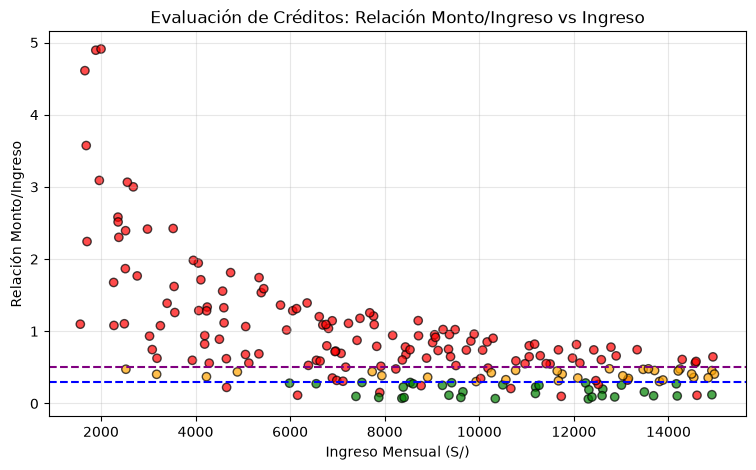

In [12]:
# Celda de Visualización
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
ingresos = np.random.randint(1500, 15000, n)
montos = np.random.randint(500, 10000, n)
morosos = np.random.choice([True, False], size=n, p=[0.2, 0.8])

relaciones, acciones = [], []
for ing, mon, mor in zip(ingresos, montos, morosos):
    rel = mon / ing
    acc, _ = agente_credito(ing, mon, mor)
    relaciones.append(rel)
    acciones.append(acc)

colores_map = {"aprobar": "green", "aprobar con condiciones": "orange", "rechazar": "red"}
colores = [colores_map[a] for a in acciones]

plt.figure(figsize=(9, 5))
plt.scatter(ingresos, relaciones, c=colores, alpha=0.7, edgecolors='k')
plt.axhline(0.3, color='blue', linestyle='--', label='Límite 0.30')
plt.axhline(0.5, color='purple', linestyle='--', label='Límite 0.50')
plt.title('Evaluación de Créditos: Relación Monto/Ingreso vs Ingreso')
plt.xlabel('Ingreso Mensual (S/)')
plt.ylabel('Relación Monto/Ingreso')
plt.grid(True, alpha=0.3)
plt.show()

## Ejercio concluido 1